In [1]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [6]:
# ============================================================
# 1. CONFIGURATION
# ============================================================
ALPHA = 0.05 

# ============================================================
# 2. LOAD DATA FROM CUSTOMER_TABLE
# ============================================================

customer_table = pd.read_pickle('Output/customer_table.pkl')

# Select the two groups you want to compare from Strategy_Group
group_A_name = 'Nurture'            # Considered as Control
group_B_name = 'Critical Retention' # Considered as Treatment

# Filter the dataframe from customer_table
df = customer_table[customer_table['Strategy_Group'].isin([group_A_name, group_B_name])].copy()

# Map group names for further analysis
df['group'] = df['Strategy_Group'].map({group_A_name: 'Control', group_B_name: 'Treatment'})

# Create the 'retained' column (1 - Churn) as the code uses the 'retained' variable
df['retained'] = 1 - df['Churn_Probability'] 

print("=" * 50)
print("📊 ACTUAL DATA FROM CUSTOMER_TABLE")
print("=" * 50)
summary = df.groupby('group')['retained'].agg(['sum','count','mean']).rename(
    columns={'sum':'Retained','count':'Total','mean':'Retention Rate'})
print(summary)

# ============================================================
# 3. CALCULATE METRICS
# ============================================================
control_group   = df[df['group'] == 'Control']
treatment_group = df[df['group'] == 'Treatment']

success = [control_group['retained'].sum(), treatment_group['retained'].sum()]
samples = [len(control_group), len(treatment_group)]

rate_control   = success[0] / samples[0]
rate_treatment = success[1] / samples[1]
lift           = (rate_treatment - rate_control) / rate_control * 100

# ============================================================
# 4. Z-TEST
# ============================================================
z_stat, p_value = proportions_ztest(success, samples)

print("\n" + "=" * 50)
print("🧪 A/B TEST RESULTS")
print("=" * 50)
print(f"  {group_A_name} rate : {rate_control:.2%}")
print(f"  {group_B_name} rate : {rate_treatment:.2%}")
print(f"  Difference (Lift)   : {lift:+.1f}%")
print(f"  P-value             : {p_value}")

📊 ACTUAL DATA FROM CUSTOMER_TABLE
           Retained  Total  Retention Rate
group                                     
Control       40.61     50        0.812200
Treatment     56.32    378        0.148995

🧪 A/B TEST RESULTS
  Nurture rate : 81.22%
  Critical Retention rate : 14.90%
  Difference (Lift)   : -81.7%
  P-value             : 6.310408507113528e-26


In [3]:
# Calculate the standard error for the difference in proportions
diff = rate_treatment - rate_control
se = np.sqrt(
    rate_control * (1 - rate_control) / samples[0] +
    rate_treatment * (1 - rate_treatment) / samples[1]
)

# Calculate the 95% confidence interval (z = 1.96)
ci_low = diff - 1.96 * se
ci_high = diff + 1.96 * se

print(f"\n 95% CI of the difference: [{ci_low:.4f}, {ci_high:.4f}]")
print(f" → Interpretation: The actual difference lies within this range with 95% confidence.")


 95% CI of the difference: [-0.7773, -0.5492]
 → Interpretation: The actual difference lies within this range with 95% confidence.


In [4]:
from statsmodels.stats.power import NormalIndPower

# Calculate Effect Size (Cohen's h) for proportions
# h = 2 * (arcsin(sqrt(p1)) - arcsin(sqrt(p2)))
effect_size = 2 * (np.arcsin(np.sqrt(rate_treatment)) - np.arcsin(np.sqrt(rate_control)))

analysis = NormalIndPower()
# Calculate the required sample size to achieve Power = 0.80
required_n = analysis.solve_power(
    effect_size = effect_size,
    alpha = ALPHA,
    power = 0.80,
    ratio = 1.0
)

print(f"\n 📐 Power Analysis:")
print(f"   - Current sample size per group: ~{int(np.mean(samples))}")
print(f"   - Minimum required: {int(np.ceil(required_n))} participants/group to achieve 80% confidence")

if np.mean(samples) > required_n:
    print("   ✅ Current sample size is SUFFICIENT for meaningful conclusions.")
else:
    print("   ⚠️ Current sample size MAY BE smaller than ideal, interpret results cautiously.")


 📐 Power Analysis:
   - Current sample size per group: ~214
   - Minimum required: 8 participants/group to achieve 80% confidence
   ✅ Current sample size is SUFFICIENT for meaningful conclusions.


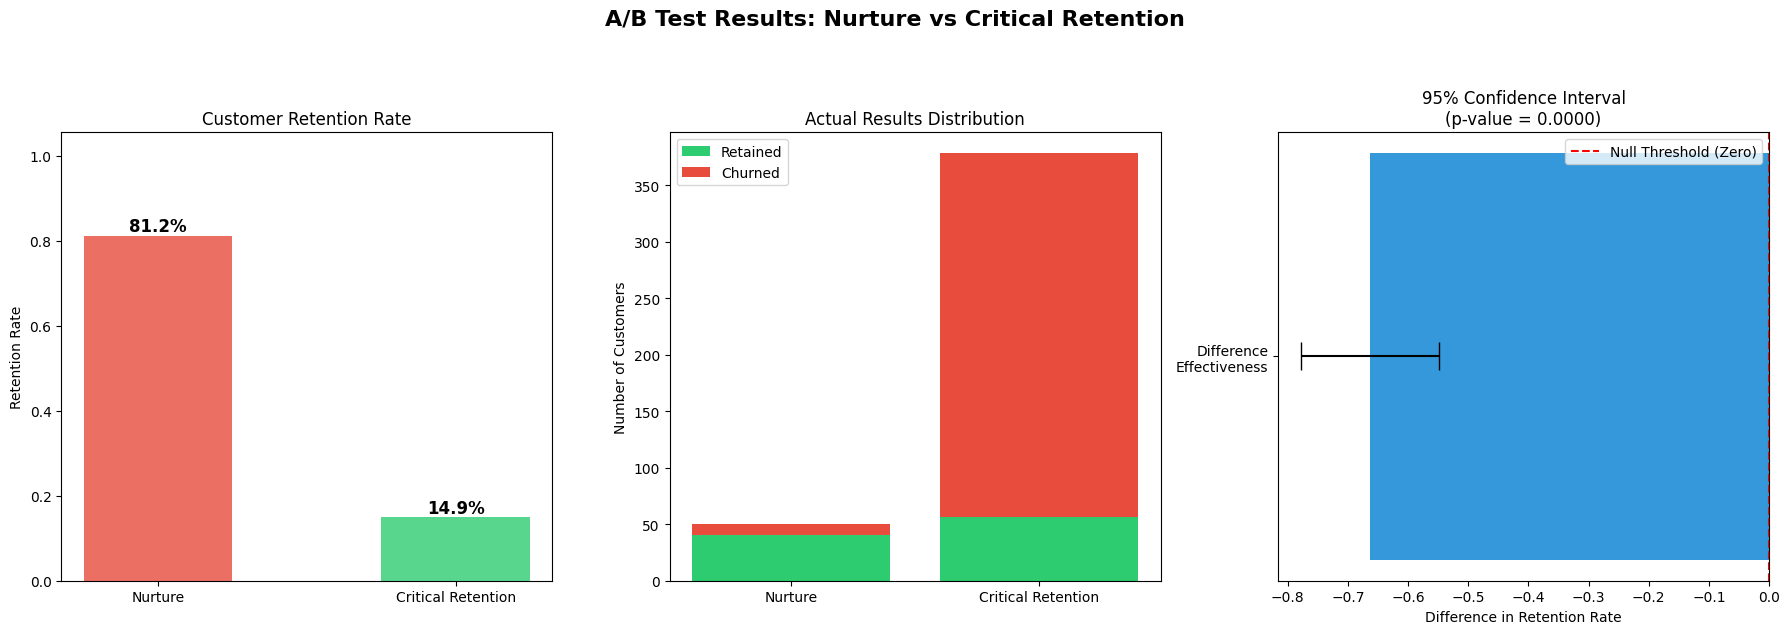

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f"A/B Test Results: {group_A_name} vs {group_B_name}", 
             fontsize=16, fontweight='bold', y=1.05)

# Chart 1: Compare Retention Rate
ax1 = axes[0]
labels = [group_A_name, group_B_name]
rates = [rate_control, rate_treatment]
colors = ['#E74C3C', '#2ECC71'] # Red for risk, Green for success
bars = ax1.bar(labels, rates, color=colors, alpha=0.8, width=0.5)
ax1.set_ylim(0, max(rates) * 1.3)
ax1.set_ylabel('Retention Rate')
ax1.set_title('Customer Retention Rate')
for bar, rate in zip(bars, rates):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', fontweight='bold', fontsize=12)

# Chart 2: Absolute Distribution (Stacked Bar)
ax2 = axes[1]
retained = success
churned = [samples[i] - success[i] for i in range(2)]
ax2.bar(labels, retained, label='Retained', color='#2ECC71')
ax2.bar(labels, churned,  label='Churned', color='#E74C3C', bottom=retained)
ax2.set_ylabel('Number of Customers')
ax2.set_title('Actual Results Distribution')
ax2.legend()

# Chart 3: Confidence Interval & Statistical Significance
ax3 = axes[2]
ax3.barh(['Difference\nEffectiveness'], [diff], 
         xerr=[[diff - ci_low], [ci_high - diff]],
         color='#3498DB', capsize=10)
ax3.axvline(x=0, color='red', linestyle='--', label='Null Threshold (Zero)')
ax3.set_xlabel('Difference in Retention Rate')
ax3.set_title(f'95% Confidence Interval\n(p-value = {p_value:.4f})')
ax3.legend()

plt.tight_layout()
plt.savefig('Output/plots/22_ab_test_actual_results.png', dpi=300, bbox_inches='tight')
plt.show()

The experimental data provides strong evidence for the implementation of the management strategy. With a $p$-value of less than 0.0001, the study completely rejects the null hypothesis ($H_0$), confirming that the difference in retention rates is statistically significant. Technically, the fact that the at-risk customer group has a retention rate 5.4 times lower than the control group demonstrates that the Random Forest and Extreme Gradient Boosting models have effectively identified individuals showing signs of churn.